In [4]:
import sys
sys.path.append('../')

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from helpers.cm26 import DatasetCM26, read_datasets
from helpers.selectors import *
from helpers.operators import Coarsen, Filtering, Subsampling, CoarsenKochkov, CoarsenWeighted, CoarsenKochkovMinMax
from helpers.state_functions import *

#import hvplot.xarray
import hvplot
import cmocean

%load_ext autoreload
%autoreload 3

# Screening models for offline analysis

In [5]:
def read_skill(exp='subfilter/FGR3/EXP1', factors=[4,9,12,15], base_path='/scratch/pp2681/mom6/CM26_ML_models/ocean3d/'):
    ds = {}
    for factor in factors:
        data = xr.open_dataset(f'{base_path}/{exp}/skill-test/factor-{factor}.nc', chunks={'zl':1})
        data['zl'] = -data['zl']
        ds[factor] = data
        
    return ds

In [54]:
import cmocean
def plot_metric(exp=None, metric='R2',vmin=-1,vmax=1):
    data = xr.concat([exp[factor][metric] for factor in [4,9,12,15]], dim='factor')
    data.drop_vars(['zl']).plot(x='factor', y='zl',cmap=cmocean.cm.balance, vmin=vmin, vmax=vmax, cbar_kwargs={'label':''})
    plt.yticks(np.arange(10),[5, 55, 110, 180,330, 730,1500,2500,3500,4500]);
    plt.ylabel('Depth, m')
    plt.xticks(np.arange(4),[4,9,12,15]);
    if metric == 'R2':
        title_str = '$R^2$'
    elif metric == 'corr':
        title_str = 'Correlation'
    elif metric == 'opt_scaling':
        title_str = 'Optimal scaling'
    
    mean_val = float(data.mean())
    std_val = float(data.std())
    plt.title(metric+'\n [mean/std]=[%.3f,%.3f]' % (mean_val,std_val))
    
    plt.xlabel('Coarsegraining factor')
    plt.gca().invert_yaxis()

In [55]:
ann_no_scaling = read_skill('subfilter/FGR3/EXP-32-32/ANN');

In [56]:
ann_scaling = read_skill('subfilter/FGR3/EXP-32-32/repeat');

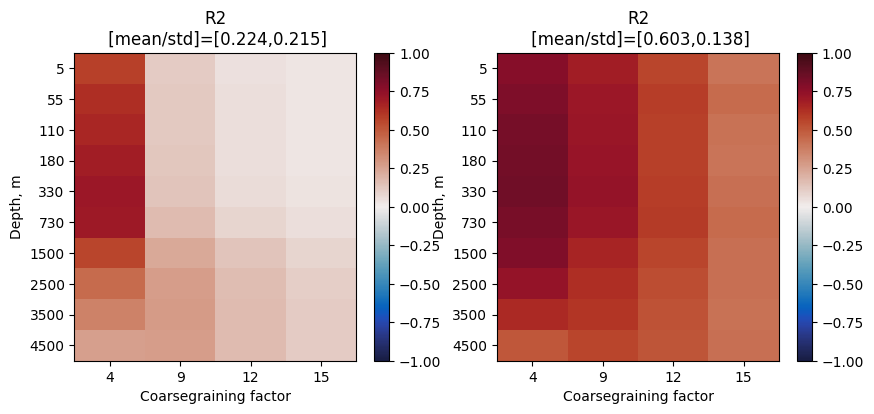

In [57]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plot_metric(ann_no_scaling)
plt.subplot(1,2,2)
plot_metric(ann_scaling)

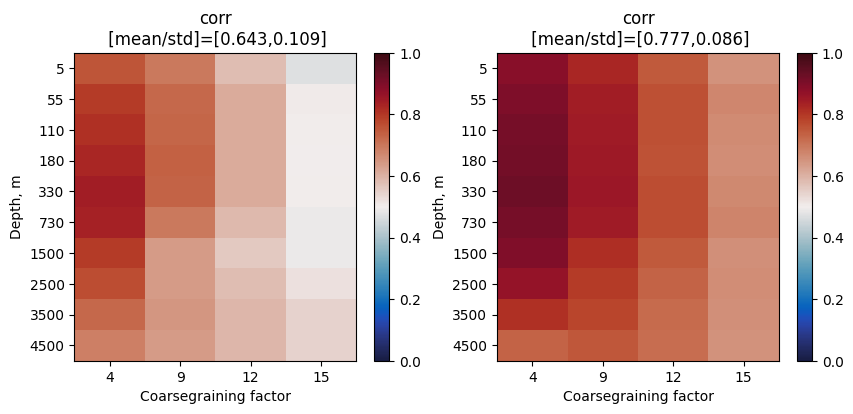

In [12]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plot_metric(ann_no_scaling, 'corr')
plt.subplot(1,2,2)
plot_metric(ann_scaling, 'corr')

# Reading data on Greene

In [13]:
ds = read_datasets(['test'], [4], subfilter='subfilter-large')['test-4'].select2d(time=0,zl=0)

Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-4


In [22]:
SGS_KE = - 0.5 * ds.nanvar(ds.data.Txx + ds.data.Tyy)
Tdd = 0.5 * ds.nanvar(ds.data.Txx - ds.data.Tyy)
Txy = ds.nanvar(ds.data.Txy)

In [19]:
EXP1 = import_ANN('/scratch/pp2681/mom6/CM26_ML_models/ocean3d/subfilter/FGR3/EXP-32-32/repeat/model/Tall.nc')
EXP2 = import_ANN('/scratch/pp2681/mom6/CM26_ML_models/ocean3d/subfilter/FGR3/EXP-32-32/ANN/model/Tall.nc')

In [32]:
ann1 = ds.state.ANN(ann_Tall=EXP1,gradient_features=['sh_xy', 'sh_xx', 'rel_vort'])
ann2 = ds.state.ANN(ann_Tall=EXP2,gradient_features=['sh_xy', 'sh_xx', 'rel_vort'], dimensional_scaling=False)

In [33]:
SGS_KEf = lambda x: - 0.5 * ds.nanvar(x['Txx'] + x['Tyy'])
Tddf = lambda x: 0.5 * ds.nanvar(x['Txx'] - x['Tyy'])
Txyf = lambda x: ds.nanvar(x['Txy'])

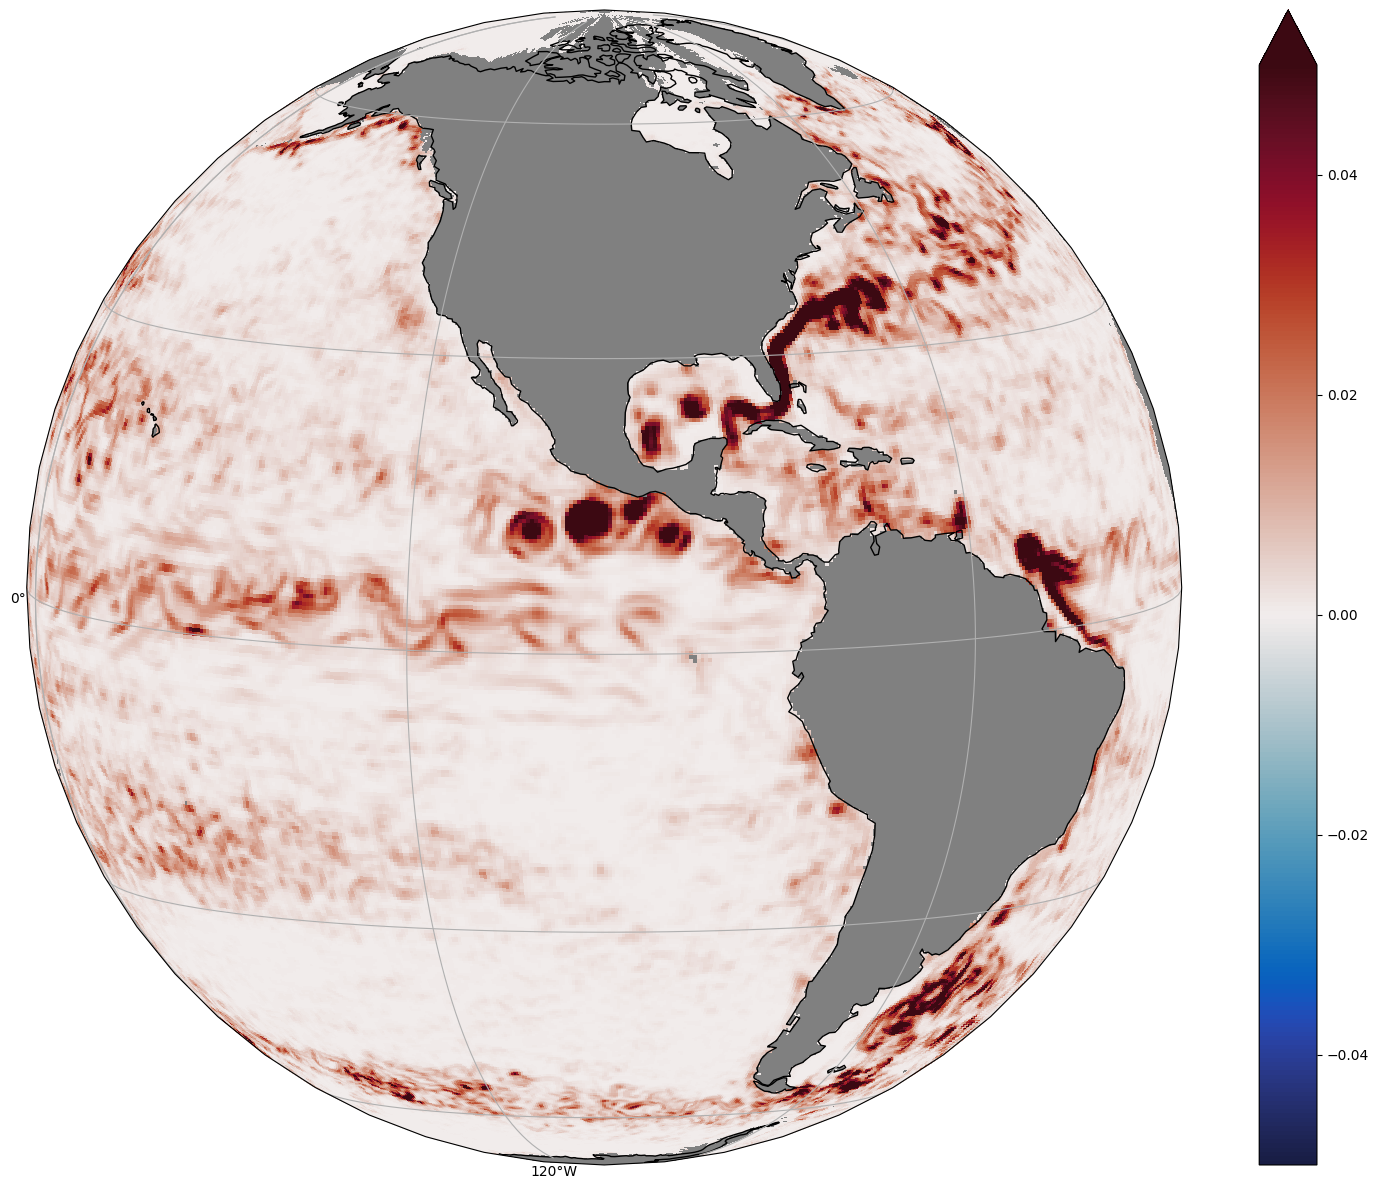

In [34]:
plot(SGS_KE,vmin=-0.05, vmax=0.05, selector=select_globe)

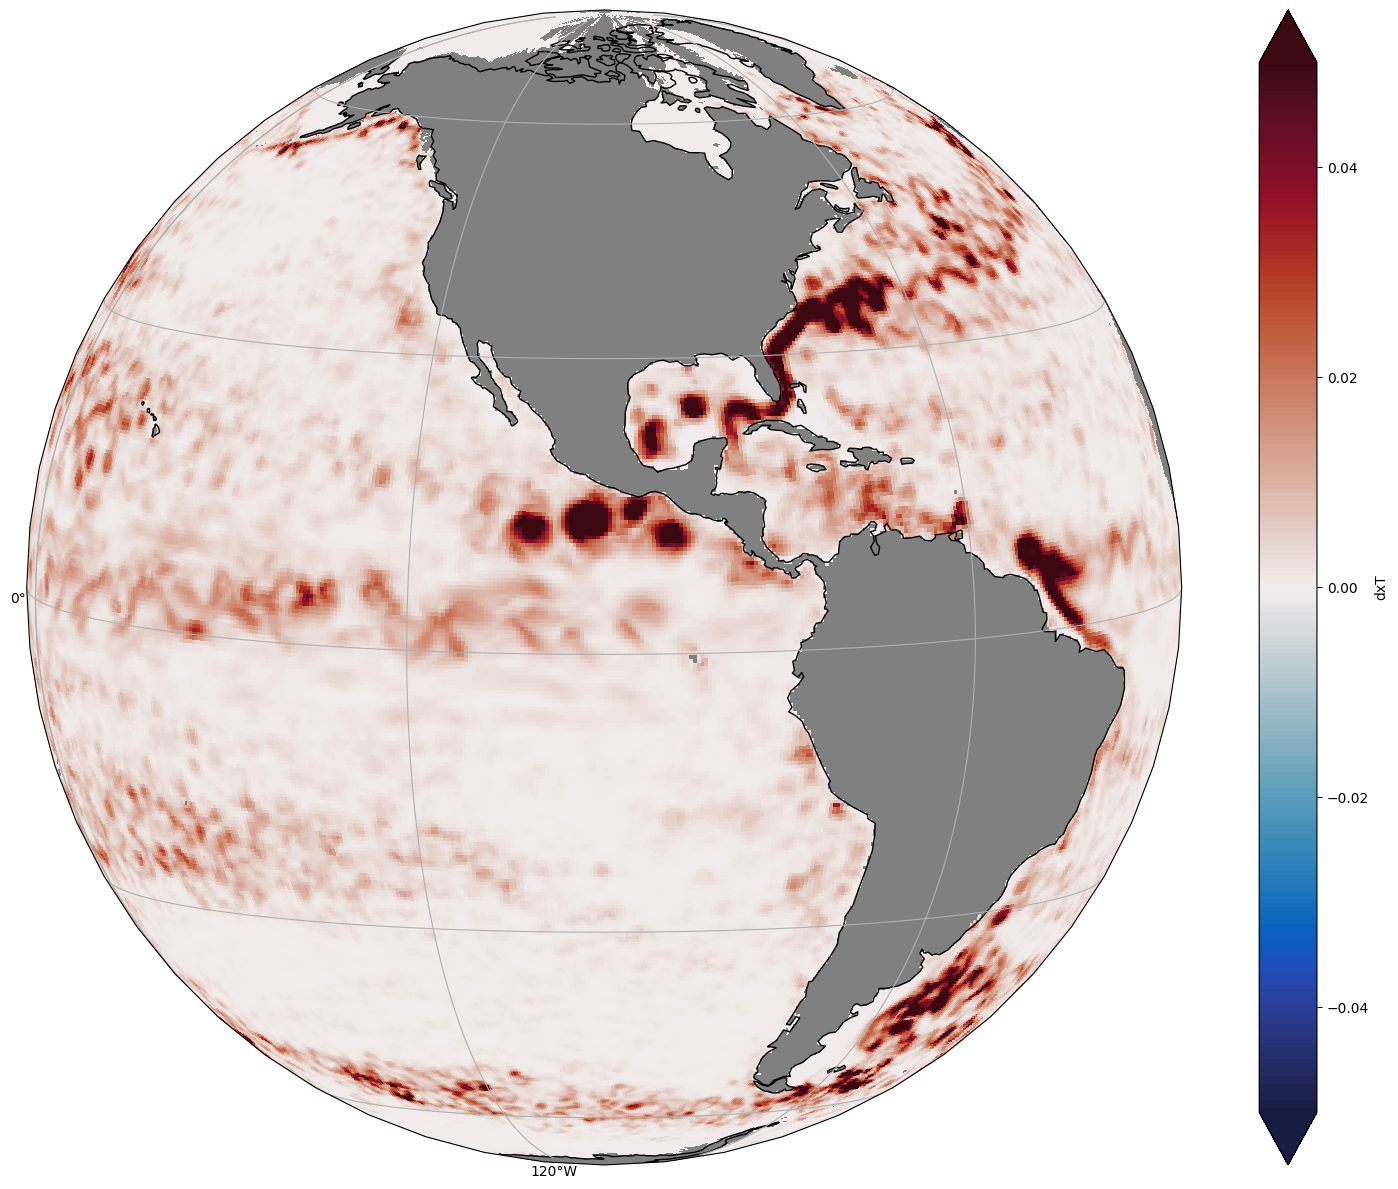

In [35]:
plot(SGS_KEf(ann1),vmin=-0.05, vmax=0.05, selector=select_globe)

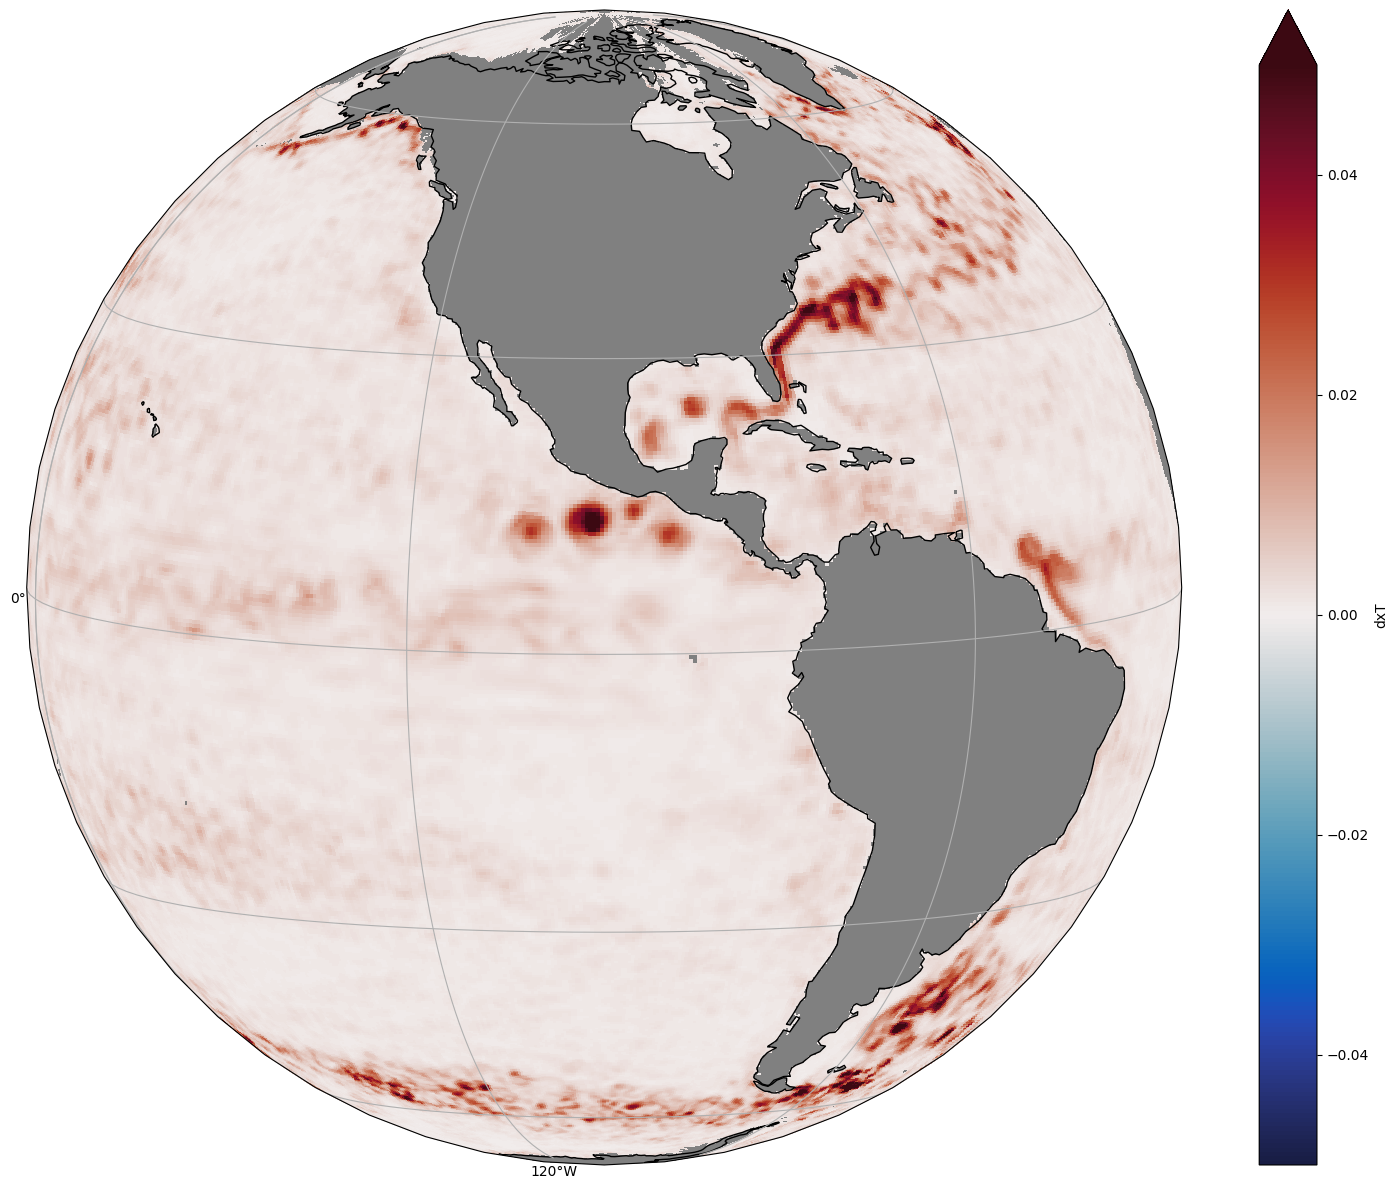

In [37]:
plot(SGS_KEf(ann2),vmin=-0.05, vmax=0.05, selector=select_globe)

In [42]:
ds = read_datasets(['test'], [9], subfilter='subfilter-large')['test-9'].select2d(time=0,zl=5)

Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-9


In [44]:
SGS_KE = - 0.5 * ds.nanvar(ds.data.Txx + ds.data.Tyy)
Tdd = 0.5 * ds.nanvar(ds.data.Txx - ds.data.Tyy)
Txy = ds.nanvar(ds.data.Txy)

In [43]:
ann1 = ds.state.ANN(ann_Tall=EXP1,gradient_features=['sh_xy', 'sh_xx', 'rel_vort'])
ann2 = ds.state.ANN(ann_Tall=EXP2,gradient_features=['sh_xy', 'sh_xx', 'rel_vort'], dimensional_scaling=False)

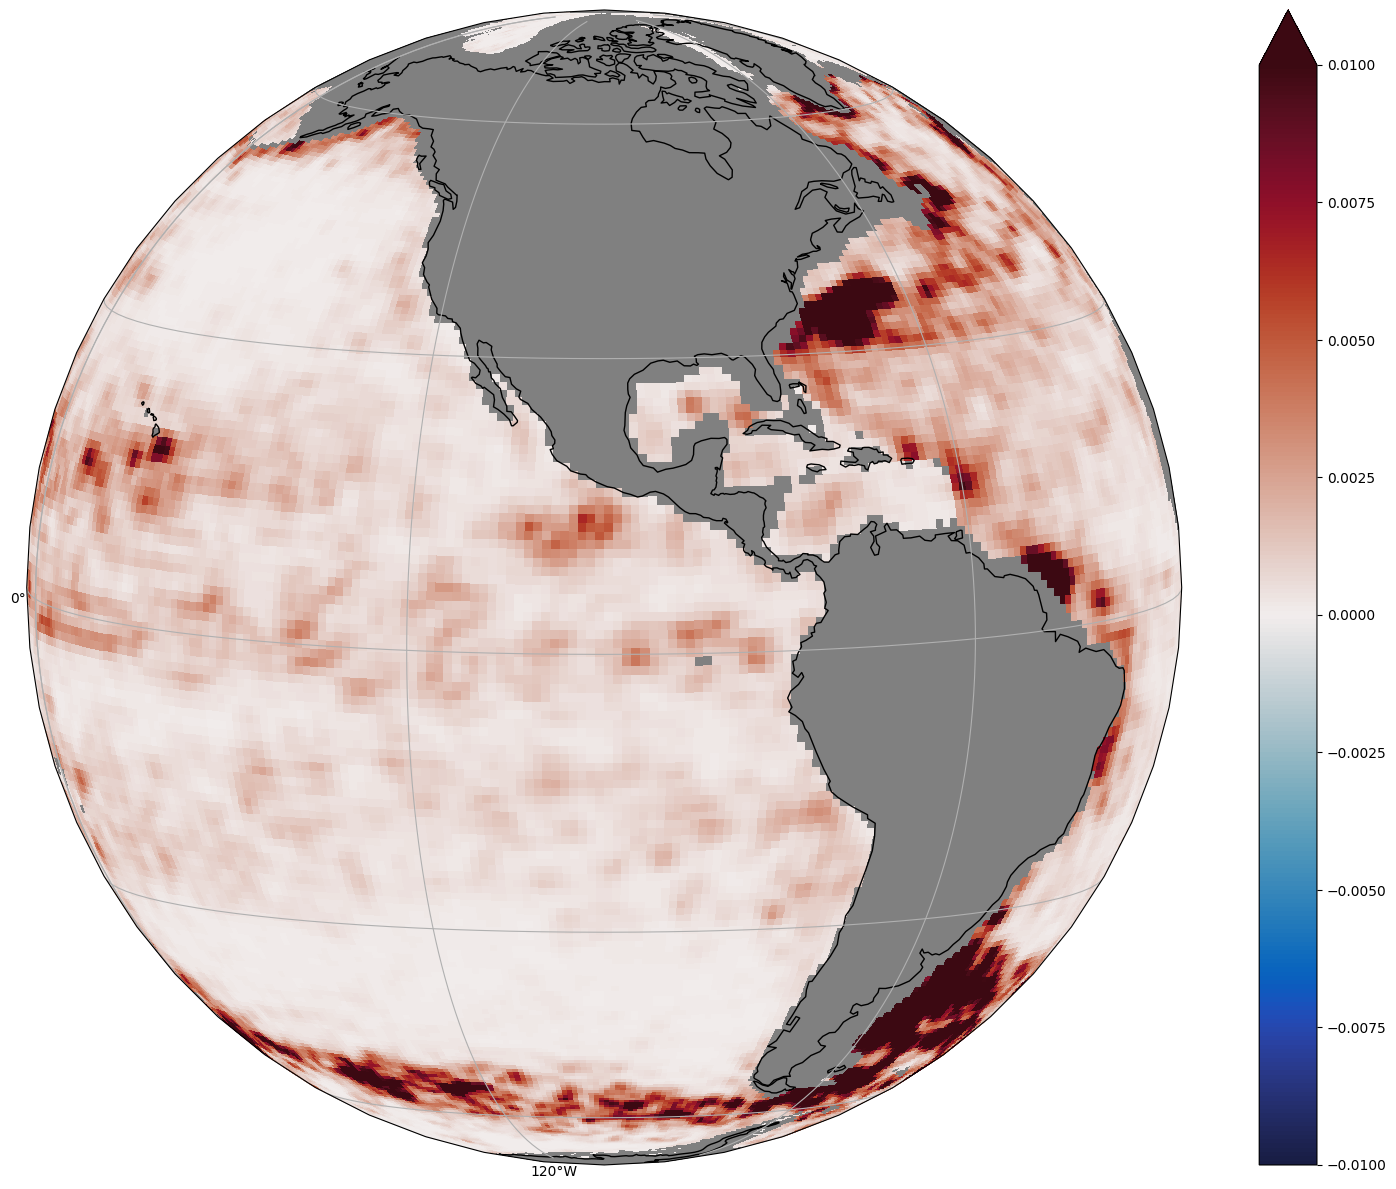

In [50]:
plot(SGS_KE,vmin=-0.01, vmax=0.01, selector=select_globe)

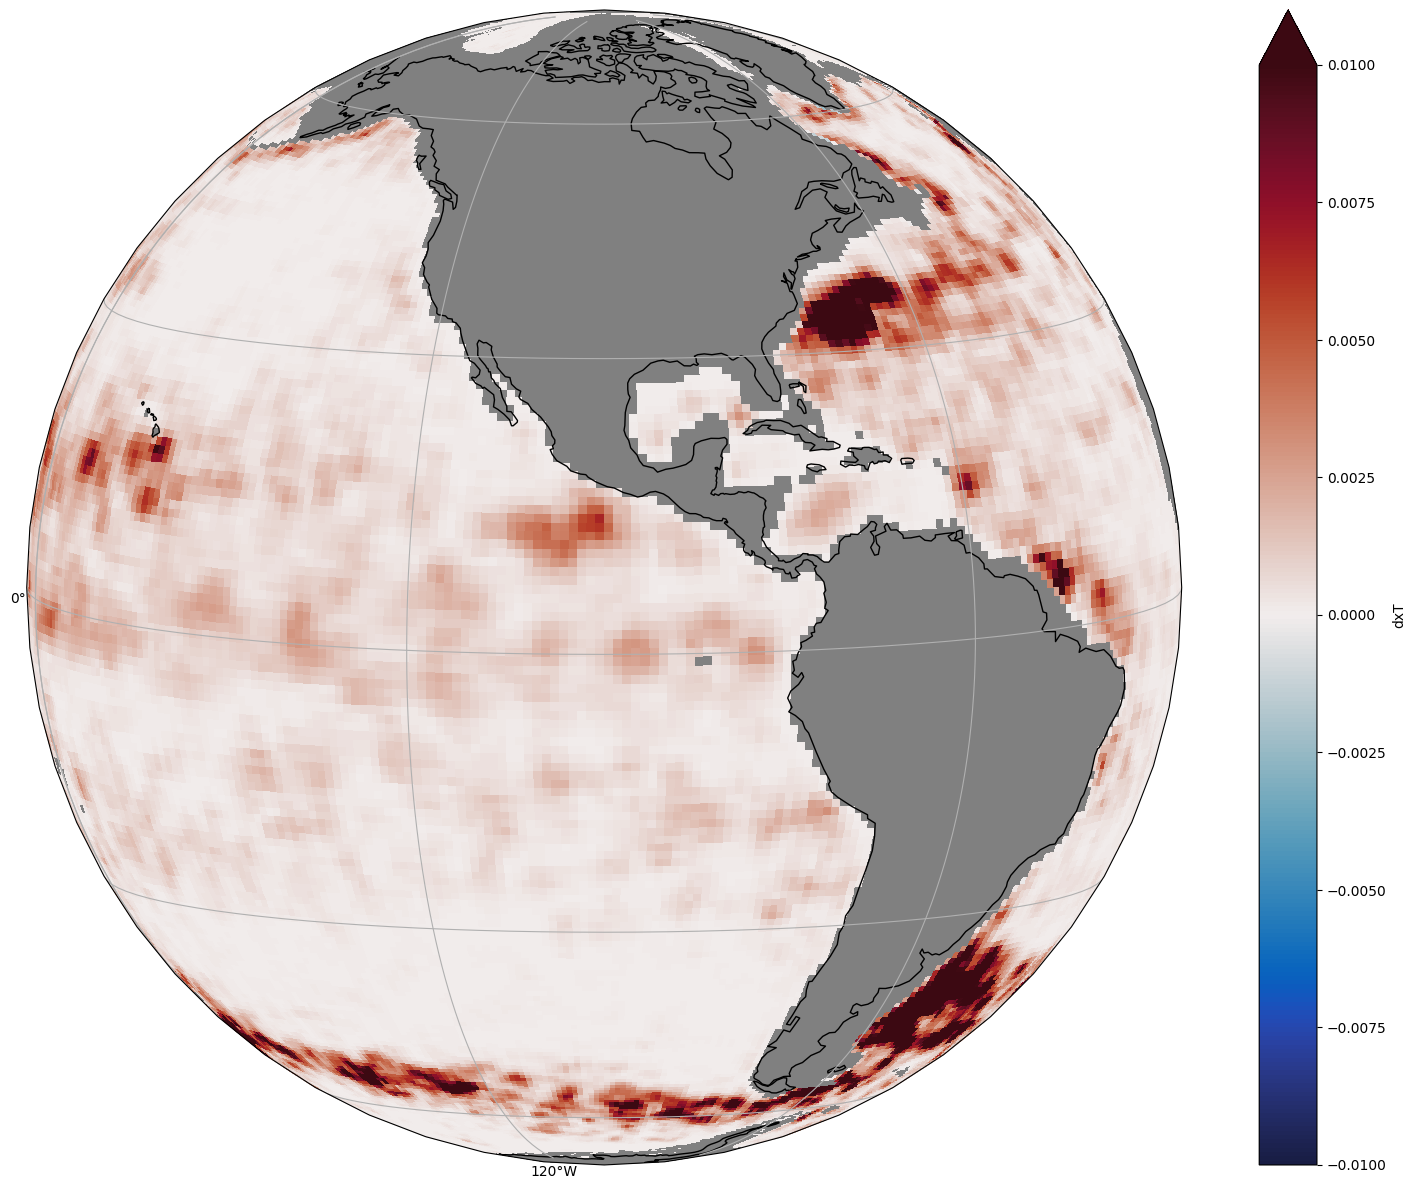

In [51]:
plot(SGS_KEf(ann1),vmin=-0.01, vmax=0.01, selector=select_globe)

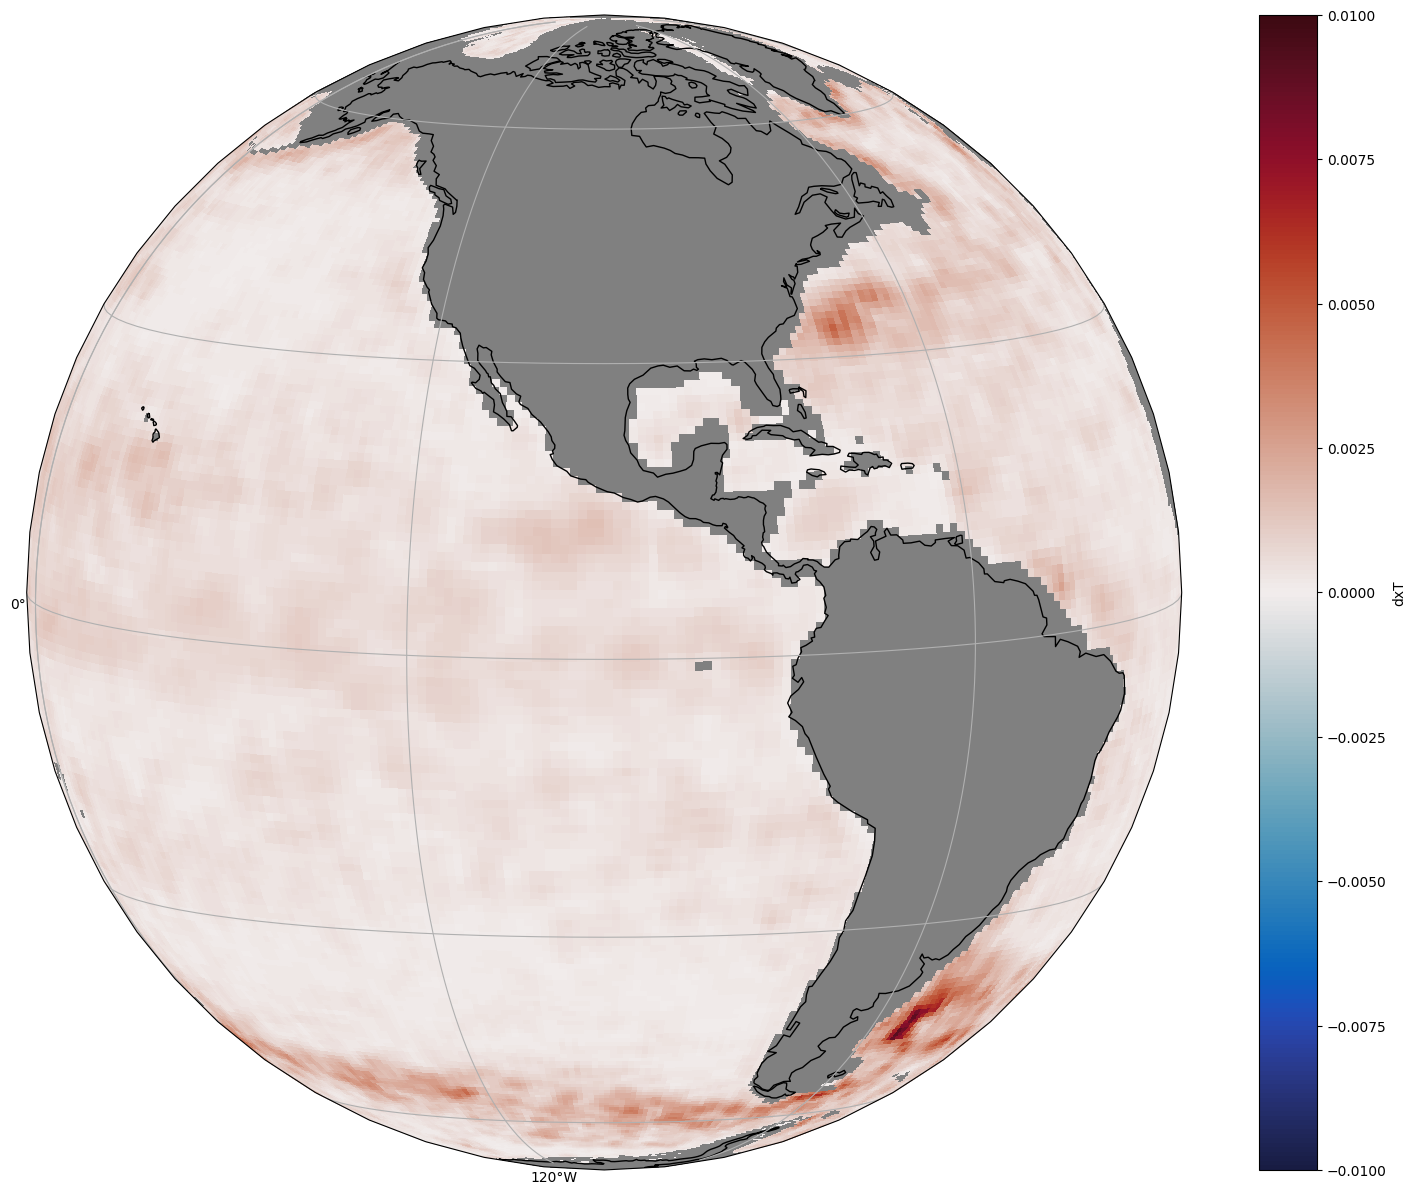

In [52]:
plot(SGS_KEf(ann2),vmin=-0.01, vmax=0.01, selector=select_globe)

In [53]:
ds.data.zl

<xarray.DataArray 'zl' ()> Size: 8B
array(728.69207764)
Coordinates:
    zl       float64 8B 728.7
    time     object 8B 0199-01-13 12:00:00